# Mini Batch Gradient Descent

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [40]:
# dataset loading
from sklearn.datasets import load_diabetes
x,y = load_diabetes(return_X_y=True)

In [41]:
# data split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [42]:
# sklearn for comparison
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_sk = lr.predict(x_test)

from sklearn.metrics import r2_score
r2_sk = r2_score(y_test, y_pred_sk)
print('R2_score sklearn =',r2_sk)
print('Intercept =',lr.intercept_)
print('Coefficients =',lr.coef_)

R2_score sklearn = 0.4399338661568968
Intercept = 151.88331005254167
Coefficients = [  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]


In [43]:
# custom class mini_batch gd
class mini_batch:
    def __init__(self, learning_rate, epochs, batch_size):
        self.epochs = epochs
        self.loss_list = []
        self.n = learning_rate
        self.intercept_ = None
        self.coef_ = None
        self.batch_size = batch_size
    
    def fit(self, x_train, y_train):
        self.intercept_ = 0
        self.coef_ = np.ones(x_train.shape[1])

        for i in range(self.epochs):
            for j in range(int(x_train.shape[0]/self.batch_size)):      # i.e number of batches
                # assuming x is batch size, hence selectig x random rows to put in batch
                # random.sample(list name, x) method
                # returns x random elements from the list mentioned
                idx = random.sample(range(x_train.shape[0]), self.batch_size)

                # vectorization
                y_pred = self.intercept_ + np.dot(x_train[idx], self.coef_)     # array with 10 elements

                # update intercept
                grad_intercept = (-2/self.batch_size) * np.sum(y_train[idx] - y_pred)
                self.intercept_ -= (self.n * grad_intercept)

                # update coef
                grad_coef = (-2/self.batch_size) * np.dot((y_train[idx] - y_pred), x_train[idx])
                self.coef_ -= (self.n * grad_coef)
            
            prediction = self.intercept_ + np.dot(x_train, self.coef_)
            loss = np.mean((y_train - prediction)**2)
            self.loss_list.append(loss)
            print(f'step {i} | loss = {loss}')
        
        print('Final parameters...')
        print('Intercept =',self.intercept_)
        print('Coefficients =',self.coef_)
    
    def predict(self, x_test):
        return self.intercept_ + np.dot(x_test, self.coef_)

In [44]:
import time

In [45]:
gd = mini_batch(0.1,1000, 35)
start = time.time()
gd.fit(x_train, y_train)
print('Training time :',time.time() - start)

step 0 | loss = 6218.225521599592
step 1 | loss = 5877.742921379339
step 2 | loss = 5787.799804712441
step 3 | loss = 5783.55267815385
step 4 | loss = 5633.921450059812
step 5 | loss = 5562.99341653903
step 6 | loss = 5525.025272303047
step 7 | loss = 5444.122666543748
step 8 | loss = 5372.88016766078
step 9 | loss = 5377.0479227417645
step 10 | loss = 5262.947890002942
step 11 | loss = 5185.247815486957
step 12 | loss = 5133.542206881898
step 13 | loss = 5085.423184364832
step 14 | loss = 5036.427005379349
step 15 | loss = 4979.412989601949
step 16 | loss = 4940.940964230671
step 17 | loss = 4916.606955482112
step 18 | loss = 4858.948442549094
step 19 | loss = 4799.621794390562
step 20 | loss = 4805.345858101751
step 21 | loss = 4713.072353669086
step 22 | loss = 4672.945031504839
step 23 | loss = 4641.047946216811
step 24 | loss = 4605.761017736302
step 25 | loss = 4584.851766267378
step 26 | loss = 4541.987705862091
step 27 | loss = 4502.635296252936
step 28 | loss = 4471.2507953329

In [46]:
# evaluation
y_pred_cc = gd.predict(x_test)
r2_cc = r2_score(y_test, y_pred_cc)
print(r2_cc)

0.4471232999980582


In [51]:
gd2 = mini_batch(0.2,1000, 35)
start = time.time()
gd2.fit(x_train, y_train)
print('Training time :',time.time() - start)

step 0 | loss = 5847.489736829283
step 1 | loss = 5699.035371453452
step 2 | loss = 5660.6991423172785
step 3 | loss = 5455.118974423922
step 4 | loss = 5338.245379567595
step 5 | loss = 5261.592161313277
step 6 | loss = 5106.9467795559285
step 7 | loss = 5063.678479993713
step 8 | loss = 4901.864006350299
step 9 | loss = 4832.119534158282
step 10 | loss = 4732.6378878034275
step 11 | loss = 4686.718767020081
step 12 | loss = 4586.195764017235
step 13 | loss = 4608.630061924267
step 14 | loss = 4522.415780024341
step 15 | loss = 4378.054828849132
step 16 | loss = 4358.614662334748
step 17 | loss = 4270.8963125824
step 18 | loss = 4274.305696238586
step 19 | loss = 4201.456923415752
step 20 | loss = 4123.136411268926
step 21 | loss = 4090.4691963052032
step 22 | loss = 4057.8233100081616
step 23 | loss = 3996.211093754827
step 24 | loss = 3953.1163687683725
step 25 | loss = 3963.0286323743994
step 26 | loss = 3895.1373691998037
step 27 | loss = 3881.457133967746
step 28 | loss = 3843.31

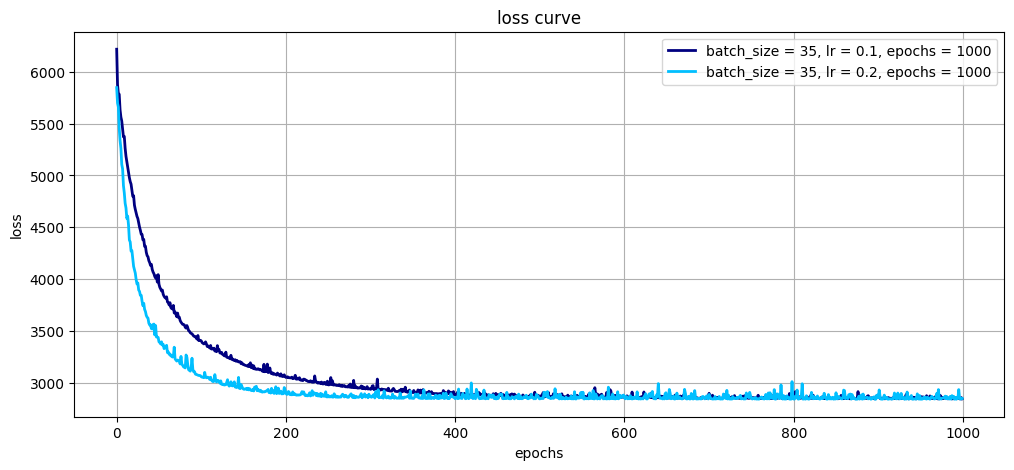

In [54]:
# loss curve
plt.figure(figsize=(12,5))
plt.plot(range(gd.epochs), gd.loss_list, color = 'navy', lw = 2, label = 'batch_size = 35, lr = 0.1, epochs = 1000')
plt.plot(range(gd2.epochs), gd2.loss_list, color = 'deepskyblue', lw = 2, label = 'batch_size = 35, lr = 0.2, epochs = 1000')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('loss curve')
plt.grid(True)
plt.legend()
plt.show()